# ImmigrationNavigator — EDA

**UC Berkeley MIDS Capstone 2026** — Team: Ale, Clover, Duc, Rohan

---

## What this notebook does

Explores the USCIS corpus built in Notebook 1 before we chunk and embed it.
The goal is to understand the data well enough to make good chunking decisions.

## What you'll learn

- How many sections the Policy Manual has and how they're structured
- Token length distribution — which sections are too long for a single chunk
- Which immigration topics are well-covered vs. sparse
- Citation URL coverage — can we deep-link to every section?
- How H-1B, F-1, OPT, and related terms appear in the corpus

## Prerequisites

Run **Notebook 1** first. This notebook reads `raw_docs.json` from S3 and re-parses the USCIS HTML for section-level analysis.

> This notebook is optional — you can skip to Notebook 3 if you just want the RAG pipeline.

## 1. Install Dependencies

In [1]:
!pip install pandas matplotlib seaborn tiktoken boto3 requests beautifulsoup4 -q

## 2. Imports and Load Corpus from S3

Loads the corpus saved by Notebook 1. Also sets up the configuration constants needed by the USCIS parser.

In [2]:
import os, json, re, time, hashlib, boto3, requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tiktoken
from bs4 import BeautifulSoup
from dataclasses import dataclass, field, asdict
from typing import Optional

# AWS
s3 = boto3.client("s3", region_name="us-east-1")
S3_BUCKET = "immigration-navigator-data"

# USCIS config — needed by the section parser below
USCIS_URL = "https://www.uscis.gov/book/export/html/68600"
CACHE_FILE = "/tmp/uscis_cache.json"
CHUNK_SIZE_TOKENS = 512
CHUNK_OVERLAP_TOKENS = 64
headers = {"User-Agent": "Mozilla/5.0"}

# Load corpus from S3
response = s3.get_object(Bucket=S3_BUCKET, Key="raw_docs.json")
all_docs = json.loads(response["Body"].read().decode("utf-8"))
print(f"Loaded {len(all_docs)} documents from S3")
print(f"Total words: {sum(d['word_count'] for d in all_docs):,}")


Loaded 3502 documents from S3
Total words: 971,801


## 3. Load Synonyms Module

Clover's `synonyms.py` contains a registry that maps user-facing terms (like 'work permit') to their legal equivalents ('employment authorization document'), form numbers, and abbreviations.

We use it here to tag each section by topic and measure corpus coverage (how many sections are actually about F-1, OPT, H-1B, etc.).

> Make sure `synonyms.py` is in `/home/sagemaker-user/` — copy it there if not.

In [3]:
from synonyms import (
    expand_query, tag_sections, print_coverage_report, get_sections_by_topic,
    RELEVANT_TOPICS, IRRELEVANT_TOPICS, is_relevant_chunk,
)

## 4. Re-parse USCIS Sections

Re-fetches and parses the USCIS Policy Manual into structured `Section` objects.

The EDA needs section-level metadata (heading level, breadcrumb, citation URL) that isn't available in the flat `raw_docs.json` format. The HTTP cache means this is fast — no re-download if content hasn't changed.

In [4]:
# ── Cache helpers ──

def load_cache() -> dict:
    """Load cached metadata (ETag, Last-Modified, file path) from disk."""
    if os.path.exists(CACHE_FILE):
        with open(CACHE_FILE, "r") as f:
            return json.load(f)
    return {}


def save_cache(metadata: dict) -> None:
    """Persist cache metadata to disk."""
    with open(CACHE_FILE, "w") as f:
        json.dump(metadata, f, indent=2)

In [5]:
def fetch_uscis_manual(force_refresh: bool = False) -> str:
    """
    Fetch the USCIS Policy Manual HTML.

    Uses HTTP ETag / Last-Modified headers so we only re-download
    when the document has actually changed.

    Args:
        force_refresh: If True, ignores cache and always re-fetches.

    Returns:
        Raw HTML string of the full policy manual.
    """
    cache = load_cache()
    headers = {"User-Agent": "Mozilla/5.0 (RAG research tool)"}

    # Add conditional request headers if we have cached validators
    if not force_refresh:
        if "etag" in cache:
            headers["If-None-Match"] = cache["etag"]
        elif "last_modified" in cache:
            headers["If-Modified-Since"] = cache["last_modified"]

    print(f"Fetching from {USCIS_URL} ...")
    response = requests.get(USCIS_URL, headers=headers, timeout=60)

    # 304 Not Modified — document hasn't changed, use cached HTML
    if response.status_code == 304:
        print("Document unchanged (304 Not Modified). Using cached version.")
        with open(cache["html_file"], "r", encoding="utf-8") as f:
            return f.read()

    response.raise_for_status()
    html = response.text
    print(f"Fetched {len(html):,} characters of HTML.")

    # Save raw HTML and update cache metadata
    html_file = "uscis_raw.html"
    with open(html_file, "w", encoding="utf-8") as f:
        f.write(html)

    cache.update({
        "etag": response.headers.get("ETag", ""),
        "last_modified": response.headers.get("Last-Modified", ""),
        "html_file": html_file,
        "fetched_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        "content_hash": hashlib.md5(html.encode()).hexdigest(),
    })
    save_cache(cache)
    print(f"Cached to '{html_file}'. Metadata saved to '{CACHE_FILE}'.")
    return html


# Run it — set force_refresh=True to bypass the cache and always re-fetch
html = fetch_uscis_manual(force_refresh=False)
print(f"\nHTML ready: {len(html):,} characters")

Fetching from https://www.uscis.gov/book/export/html/68600 ...
✅ Fetched 11,691,266 characters of HTML.


💾 Cached to 'uscis_raw.html'. Metadata saved to '/tmp/uscis_cache.json'.

HTML ready: 11,691,266 characters


In [6]:
@dataclass
class Section:
    """One parsed section of the USCIS policy manual."""
    title: str                           # Section heading text
    level: int                           # Heading level (1=H1, 2=H2, etc.)
    text: str                            # Body text under this heading
    citation_url: str                    # Deep-link URL for citing this section
    breadcrumb: list[str] = field(default_factory=list)  # Ancestor heading titles

In [7]:
def parse_sections(html: str) -> list[Section]:
    soup = BeautifulSoup(html, "html.parser")

    for tag in soup.find_all(["nav", "script", "style", "header", "footer"]):
        tag.decompose()

    sections: list[Section] = []
    heading_tags = ["h1", "h2", "h3", "h4"]
    breadcrumb_stack: list[tuple[int, str]] = []
    current_chapter_url = "https://www.uscis.gov/policy-manual"
    base = "https://www.uscis.gov"

    all_headings = soup.find_all(heading_tags)

    for i, heading in enumerate(all_headings):
        if len(heading.name) < 2:
            continue

        level = int(heading.name[1])
        title = heading.get_text(strip=True).replace('\xa0', ' ')
        inner_links = heading.find_all("a")
        heading_classes = heading.get("class") or []

        # ── Pattern 1: bookmark <h2> — update chapter URL and skip ──
        is_bookmark = False
        for a in inner_links:
            if "bookmark" in (a.get("rel") or []) and a.get("href"):
                current_chapter_url = base + a["href"]
                is_bookmark = True
                break
        if is_bookmark:
            continue

        # ── Pattern 2: level__title <h2> — TOC navigation, skip entirely ──
        # These are just the table of contents links, not real content
        if "level__title" in heading_classes:
            continue

        # ── Pattern 3: book-node-heading <h1> — actual chapter/part title ──
        # Peek at the next heading to find its bookmark URL since the
        # bookmark <h2> comes AFTER the title <h1> in the HTML
        if "book-node-heading" in heading_classes:
            for next_heading in all_headings[i+1:i+3]:
                next_links = next_heading.find_all("a")
                for a in next_links:
                    if "bookmark" in (a.get("rel") or []) and a.get("href"):
                        current_chapter_url = base + a["href"]
                        break
                break
            citation_url = current_chapter_url

        # ── Pattern 4: ck-anchor — section level heading ──
        else:
            citation_url = current_chapter_url
            for a in inner_links:
                if "ck-anchor" in (a.get("class") or []) and a.get("id"):
                    citation_url = f"{current_chapter_url}#{a['id']}"
                    break

        # ── Collect body text ──
        body_parts = []
        for sibling in heading.find_next_siblings():
            if sibling.name in heading_tags:
                break  # Stop at any same-or-higher heading
            # Collect direct content tags only — don't recurse into nested sections
            if sibling.name in ["p", "ul", "ol", "table", "div", "blockquote"]:
                # Check if this sibling contains a heading — if so, extract only
                # the text that comes before the first nested heading
                nested = sibling.find(heading_tags)
                if nested:
                    # Get text up to the nested heading only
                    for child in sibling.children:
                        if hasattr(child, 'name') and child.name in heading_tags:
                            break
                        text = child.get_text(separator=" ", strip=True) if hasattr(child, 'get_text') else str(child).strip()
                        if text:
                            body_parts.append(text)
                    break
                else:
                    text = sibling.get_text(separator=" ", strip=True)
                    if text:
                        body_parts.append(text)

        body_text = " ".join(body_parts).replace('\xa0', ' ')

        breadcrumb_stack = [(l, t) for l, t in breadcrumb_stack if l < level]
        current_breadcrumb = [t for _, t in breadcrumb_stack]
        breadcrumb_stack.append((level, title))

        sections.append(Section(
            title=title,
            level=level,
            text=body_text,
            citation_url=citation_url,
            breadcrumb=current_breadcrumb,
        ))

    return sections

sections = parse_sections(html)
print(f"Parsed {len(sections):,} sections from the USCIS manual.")

# Preview the first 5 sections
for s in sections[:5]:
    preview = s.text[:80].replace("\n", " ") + "..." if len(s.text) > 80 else s.text
    print(f"  H{s.level} | {s.title[:60]} | {preview}")

✅ Parsed 4,341 sections from the USCIS manual.
  H1 | Policy Manual | 
  H4 | About the Policy Manual | The USCIS Policy Manual is the agency’s centralized online repository for USCIS’...
  H4 | Adjudicator's Field Manual Transition | USCIS is retiring its Adjudicator's Field Manual (AFM), a collection of our immi...
  H3 | Get Updates by Email | Email Address e.g. name@email.com
  H1 | Search | 


## 5. Build EDA DataFrame

Creates a pandas DataFrame with one row per section, including:
- `char_count`, `word_count`, `token_count` — size metrics
- `has_content` — whether the section has body text (vs. heading-only)
- `breadcrumb_depth` — how deep in the hierarchy the section sits

Footnote sections are excluded at this stage — they pollute retrieval results.

In [8]:
def count_tokens(text: str) -> int:
    """Count tokens using tiktoken — mirrors what text-embedding-3-small sees."""
    enc = tiktoken.get_encoding("cl100k_base")
    return len(enc.encode(text))


# Build a DataFrame with one row per section
df = pd.DataFrame([asdict(s) for s in sections])
df["char_count"]      = df["text"].str.len()
df["word_count"]      = df["text"].str.split().str.len()
df["token_count"]     = df["text"].apply(count_tokens)
df["has_content"]     = df["char_count"] > 0
df["breadcrumb_depth"] = df["breadcrumb"].apply(len)

# Mirror the same footnote filter used in build_llama_documents
# so EDA and synonym tagging reflect what's actually in the index
df = df[~df["title"].str.lower().str.strip().str.startswith("footnote")].reset_index(drop=True)

print("✅ DataFrame built. Shape:", df.shape)
df.head()

✅ DataFrame built. Shape: (3893, 10)


,title,level,text,citation_url,breadcrumb,char_count,word_count,token_count,has_content,breadcrumb_depth
0,Policy Manual,1,,https://www.uscis.gov/policy-manual,[],0,0,0,False,0
1,About the Policy Manual,4,The USCIS Policy Manual is the agency’s centra...,https://www.uscis.gov/policy-manual,[Policy Manual],1583,235,283,True,1
2,Adjudicator's Field Manual Transition,4,USCIS is retiring its Adjudicator's Field Manu...,https://www.uscis.gov/policy-manual,[Policy Manual],697,109,148,True,1
3,Get Updates by Email,3,Email Address e.g. name@email.com,https://www.uscis.gov/policy-manual,[Policy Manual],33,4,8,True,1
4,Search,1,,https://www.uscis.gov/policy-manual/search,[],0,0,0,False,0


## 6. Summary Statistics

High-level overview of the corpus structure:
- Total sections and how many have content
- Section counts by heading level
- Token distribution (mean, median, max)
- What percentage of sections exceed the chunk size limit

In [9]:
# ── Summary statistics ──

print("── Document Structure ──────────────────────────────")
print(f"  Total sections:              {len(df):,}")
print(f"  Sections with body text:     {df['has_content'].sum():,}")
print(f"  Heading-only (no body):      {(~df['has_content']).sum():,}")

print("\n── Section counts by heading level ─────────────────")
print(df.groupby("level")["title"].count().rename("count").to_string())

print("\n── Token distribution (sections with content) ──────")
print(df[df["has_content"]]["token_count"].describe().round(1).to_string())

pct_over = (df["token_count"] > CHUNK_SIZE_TOKENS).mean() * 100
print(f"\n  Sections exceeding {CHUNK_SIZE_TOKENS}-token chunk limit: {pct_over:.1f}%")
print(f"  → These will be split further by LlamaIndex's SentenceSplitter.")

── Document Structure ──────────────────────────────
  Total sections:              3,893
  Sections with body text:     2,969
  Heading-only (no body):      924

── Section counts by heading level ─────────────────
level
1     646
2    1614
3    1631
4       2

── Token distribution (sections with content) ──────
count    2969.0
mean      274.0
std       335.6
min         3.0
25%        97.0
50%       183.0
75%       331.0
max      6092.0

  Sections exceeding 512-token chunk limit: 9.9%
  → These will be split further by LlamaIndex's SentenceSplitter.


## 7. Visualization

Three charts:
1. **Section count by heading level** — how deep is the document hierarchy?
2. **Token length distribution** — where does the chunk size limit cut off?
3. **Top 20 longest sections** — which sections will need to be split further?

💾 EDA plots saved to 'uscis_eda.png'


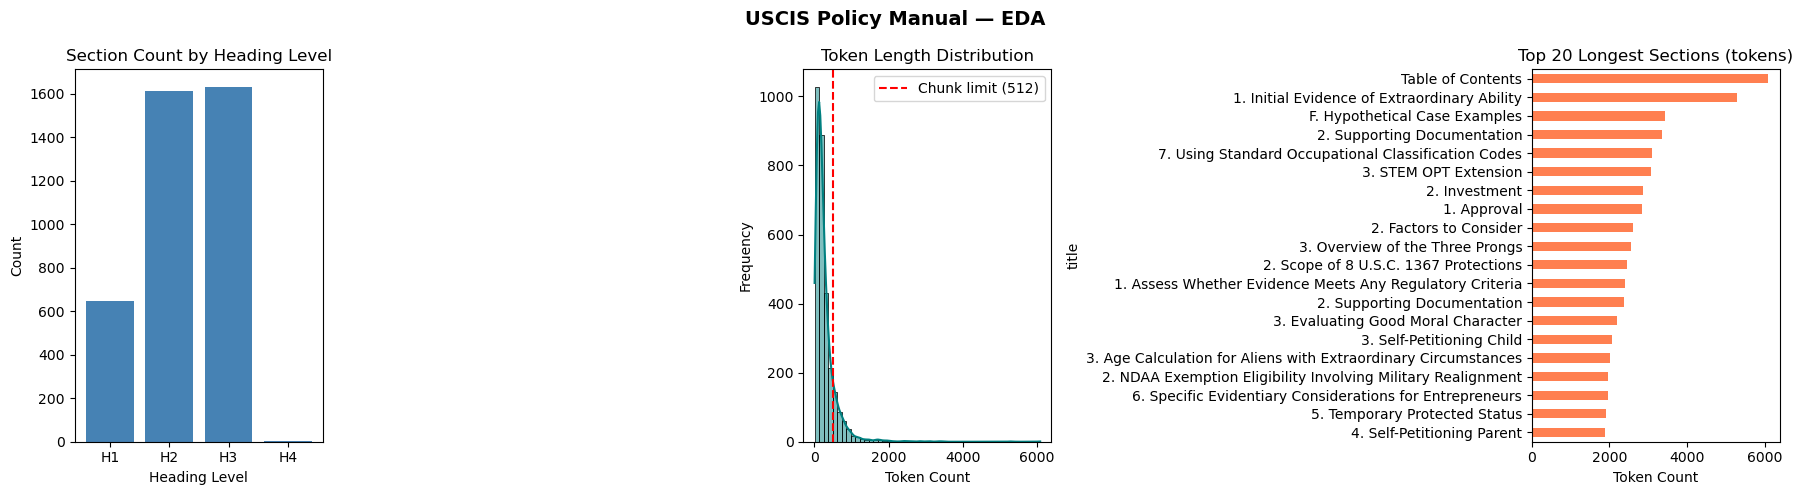

In [10]:
# ── Plots ──

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("USCIS Policy Manual — EDA", fontsize=14, fontweight="bold")

# Plot 1: Section count by heading level
level_counts = df.groupby("level")["title"].count()
axes[0].bar([f"H{l}" for l in level_counts.index], level_counts.values, color="steelblue")
axes[0].set_title("Section Count by Heading Level")
axes[0].set_xlabel("Heading Level")
axes[0].set_ylabel("Count")

# Plot 2: Token length distribution with chunk limit line
sns.histplot(df[df["has_content"]]["token_count"], bins=50, kde=True, ax=axes[1], color="teal")
axes[1].axvline(CHUNK_SIZE_TOKENS, color="red", linestyle="--", label=f"Chunk limit ({CHUNK_SIZE_TOKENS})")
axes[1].set_title("Token Length Distribution")
axes[1].set_xlabel("Token Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# Plot 3: Top 20 longest sections
top20 = df.nlargest(20, "token_count")[["title", "token_count"]].set_index("title")
top20.plot(kind="barh", ax=axes[2], color="coral", legend=False)
axes[2].set_title("Top 20 Longest Sections (tokens)")
axes[2].set_xlabel("Token Count")
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig("uscis_eda.png", dpi=150, bbox_inches="tight")
print("💾 EDA plots saved to 'uscis_eda.png'")
plt.show()

## 8. Large Section Analysis

Identifies sections with more than 10,000 tokens — these are unusually large and may need special handling. Large sections often contain tables or lists that benefit from different chunking strategies.

In [11]:
# Find suspiciously large sections
df[df["token_count"] > 10000][["title", "level", "token_count", "citation_url"]].sort_values("token_count", ascending=False)

,title,level,token_count,citation_url


## 9. Citation URL Coverage

Checks how many sections have specific deep-link URLs vs. falling back to the generic policy manual homepage. High coverage means users get precise links to the exact USCIS page that answers their question.

In [12]:
specific = df["citation_url"].str.contains("#|chapter|part|volume-[0-9]", regex=True).sum()
fallback = (df["citation_url"] == "https://www.uscis.gov/policy-manual").sum()
print(f"Specific citation URLs:  {specific:,}  ({specific/len(df)*100:.1f}%)")
print(f"Fallback (base) URLs:    {fallback:,}  ({fallback/len(df)*100:.1f}%)")

Specific citation URLs:  3,885  (99.8%)
Fallback (base) URLs:    4  (0.1%)


## 10. Keyword Coverage

Counts how many sections mention each key term: F-1, H-1B, OPT, CPT, STEM, EAD, DSO, etc.

This tells us whether our corpus has enough content on each topic to answer the MVP questions reliably.

In [13]:
keywords = ["F-1", "H-1B", "OPT", "CPT", "STEM", "EAD", "DSO", "employment authorization"]
for kw in keywords:
    count = df["text"].str.contains(kw, case=False, na=False).sum()
    print(f"  {kw:<25} {count:>4} sections")

  F-1                         55 sections
  H-1B                        23 sections
  OPT                        295 sections
  CPT                          3 sections


  STEM                       140 sections
  EAD                        438 sections
  DSO                         36 sections
  employment authorization   104 sections


## 11. Term Variation Analysis

Checks how key terms appear in the corpus — with hyphens, without, abbreviated, etc.

For example: does USCIS write 'H-1B' or 'H1B'? 'F-1' or 'F1'?
This informs the synonym registry in `synonyms.py` — if users type 'H1B' but USCIS only writes 'H-1B', we need to normalize the query.

In [14]:
import re

# Check all H1B term variations in the document
h1b_patterns = [
    r'H-1B', r'H1B', r'H1-B', r'H-1-B',
    r'H\.1\.B', r'H 1B', r'H1 B'
]

print("H1B term variations in corpus:")
for pattern in h1b_patterns:
    count = df["text"].str.count(pattern, flags=re.IGNORECASE).sum()
    print(f"  {pattern:<15} {int(count):>5} occurrences")

# Same for F1
f1_patterns = [
    r'F-1', r'F1', r'F-1B', r'F\.1',
    r'F 1', r'F1 visa', r'F-1 visa', r'F-1 student'
]

print("\nF1 term variations in corpus:")
for pattern in f1_patterns:
    count = df["text"].str.count(pattern, flags=re.IGNORECASE).sum()
    print(f"  {pattern:<15} {int(count):>5} occurrences")

# And OPT/CPT
other_patterns = [
    r'OPT', r'optional practical training',
    r'CPT', r'curricular practical training',
    r'STEM OPT', r'EAD', r'employment authorization document'
]

print("\nOther key term variations:")
for pattern in other_patterns:
    count = df["text"].str.count(pattern, flags=re.IGNORECASE).sum()
    print(f"  {pattern:<20} {int(count):>5} occurrences")

H1B term variations in corpus:
  H-1B               64 occurrences
  H1B                 0 occurrences
  H1-B                0 occurrences


  H-1-B               0 occurrences
  H\.1\.B             0 occurrences
  H 1B                0 occurrences
  H1 B                0 occurrences

F1 term variations in corpus:


  F-1               252 occurrences
  F1                  1 occurrences
  F-1B                0 occurrences
  F\.1                0 occurrences


  F 1               301 occurrences
  F1 visa             0 occurrences
  F-1 visa            0 occurrences
  F-1 student       180 occurrences

Other key term variations:


  OPT                   1541 occurrences
  optional practical training    10 occurrences
  CPT                     11 occurrences
  curricular practical training     3 occurrences


  STEM OPT                58 occurrences
  EAD                    797 occurrences
  employment authorization document    28 occurrences


## 12. Topic Tagging with Synonyms

Uses the synonym registry to tag each section by immigration topic (F-1 Student, OPT, STEM OPT, H-1B, etc.).

The coverage report shows what percentage of the corpus is tagged per topic — gaps here indicate areas where our corpus may be weak.

Untagged sections are checked at the end to verify they're genuinely irrelevant (e.g. administrative procedures, naturalization) rather than missed matches.

In [15]:
df = tag_sections(df)
print_coverage_report(df)

Tagging sections with topic categories ...


✅ Tagging complete.
   Sections with at least 1 topic tag: 1,952
   Sections with no topic tag:          1,941

── Topic Coverage Report ────────────────────────────────────────
  Topic                                    Sections  Relevance
  ----------------------------------------  --------  --------------------
  Adjustment of Status                          792  ████████████████████
  PERM Labor Certification                      741  ████████████████████
  H-1B Petition                                 722  ████████████████████
  Employment Authorization Document             493  ████████████████████
  Optional Practical Training                   360  ████████████████████
  Change of Status                              135  ████████████████████
  H-1B Extension                                107  ████████████████████
  Immigrant Petition                            103  ████████████████████
  Form I-94                                      89  █████████████████
  H-1B Specialty Occu

In [16]:
# See all sections tagged as OPT-related
opt_sections = get_sections_by_topic(df, "Optional Practical Training")
opt_sections[["title", "citation_url", "token_count"]].head(10)

,title,citation_url,token_count
0,Table of Contents,https://www.uscis.gov/policy-manual/table-of-c...,6092
1,A. Website,https://www.uscis.gov/policy-manual/volume-1-p...,367
2,A. In-Person,https://www.uscis.gov/policy-manual/volume-1-p...,79
3,1. Overview of Information Protections Codifie...,https://www.uscis.gov/policy-manual/volume-1-p...,629
4,3. USCIS Assistance,https://www.uscis.gov/policy-manual/volume-1-p...,468
5,4. Mailing Address Procedures for Aliens Prote...,https://www.uscis.gov/policy-manual/volume-1-p...,1658
6,3. USCIS Assistance,https://www.uscis.gov/policy-manual/volume-1-p...,1680
7,2. USCIS Assistance,https://www.uscis.gov/policy-manual/volume-1-p...,318
8,J. S Nonimmigrant Visa Category,https://www.uscis.gov/policy-manual/volume-1-p...,257
9,3. USCIS Website,https://www.uscis.gov/policy-manual/volume-1-p...,73


In [17]:
# What are the untagged sections about?
untagged = df[df["topic_count"] == 0]
print(f"Untagged sections: {len(untagged)}")
print(f"Heading-only (no content): {(~untagged['has_content']).sum()}")
print(f"\nSample untagged section titles:")
print(untagged[untagged["has_content"]]["title"].sample(15).tolist())

Untagged sections: 1941
Heading-only (no content): 924

Sample untagged section titles:
['1. Health-Related Inadmissibility Grounds', '2. Required Home Study Content', '1. Application Support Center Appointments', 'B. Following-to-Join Refugee Grounds of Inadmissibility and Waivers', '2. Signature Requirements', '2. Qualifying for Modification to the Oath', 'B. Effect of Returning to the United States During the Statutory 3-Year or 10-Year Period After Departure or Removal', '4. Job Creation', '3. Requests Improperly Filed by Attorneys or Authorized Representatives', 'B. Qualifying Military Service', '1. Initial Filing', '2. Born in the United States', 'B. Reissuing Non-Deliverable Secure Identity Documents', '1. Adjudication', 'B. Background']
